In [1]:
#Modules
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.ticker as ticker
#from matplotlib import rc
#import latex

import random
import math
import scipy 
from scipy.optimize import fsolve
from random import uniform

import astropy
from astropy import modeling
from astropy.convolution import convolve, Gaussian2DKernel, Moffat2DKernel

import photutils
from photutils.psf import MoffatPSF

Text(0, 0.5, '$y$  [pixels]')

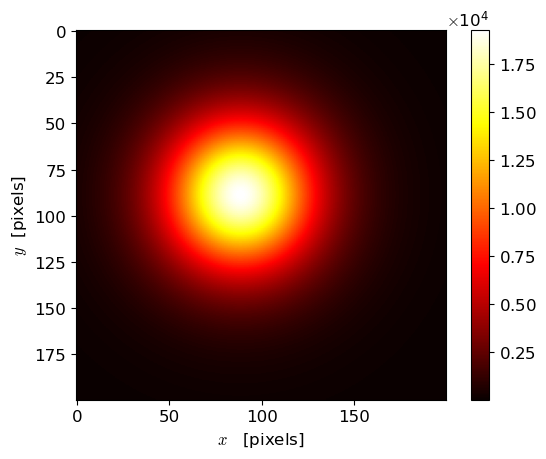

In [17]:
#Want to use photutils version of the Moffat distribution since they have a formula for calculating the alpha from the FWHM and an assumed beta
#within the docs
#This is a recreation using the documentation

#Choose a value for beta
beta = 5

#Input FWHM value (in pixels for this case)
FWHM = 3

#Compute alpha
denominatorTerm = 2*np.sqrt(2**(1/beta) - 1)
alpha = FWHM/denominatorTerm

#Generate a mesh grid to place the source onto 

xCoords = np.linspace(1,10,200)

#Create the y coordinates
yCoords = np.linspace(1,10,200)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Set the pixel values for the center of the source
xCenter = 5
yCenter = 5

#Compute the distances from the source center to each point within the mesh grid
deltaX = xField - xCenter
deltaY = yField - yCenter

#Set a flux value
flux = 10**3

#Use the formula from photutils to compute the source's Moffat

moffat = flux* ((beta - 1)/np.pi * alpha**2) * (1 + ((deltaX**2 + deltaY**2)/alpha**2))**(-1*beta)

#Plot the moffat distribution

plt.imshow(moffat, cmap = 'hot')

cbar = plt.colorbar()
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.update_ticks()

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12

#Enable the use of latex writing for the plot
#plt.rcParams['text.usetex'] = True
plt.xlabel(r'$x$   [pixels]')
plt.ylabel(r'$y$  [pixels]')

Text(0, 0.5, '$y$  [pixels]')

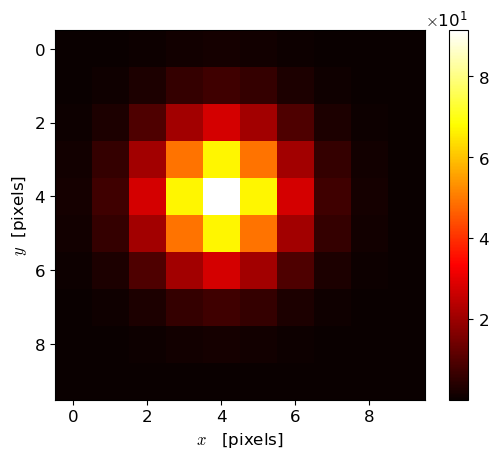

In [23]:
#Creating an example moffat using the photutils functionality

#Choose a value for beta
beta = 10

#Input FWHM value (in pixels for this case)
FWHM = 3

#Compute alpha
denominatorTerm = 2*np.sqrt(2**(1/beta) - 1)
alpha = FWHM/denominatorTerm

#Generate a mesh grid to place the source onto 

#Create the x coordinates
xCoords = np.linspace(1,10,10)

#Create the y coordinates
yCoords = np.linspace(1,10,10)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Set the pixel values for the center of the source
xCenter = 5
yCenter = 5

#Set a flux value
flux = 10**3

#Create the moffat model for the data

moffatModel = MoffatPSF(flux = flux, x_0 = xCenter, y_0 = yCenter, alpha = alpha, beta = beta)

#Compute the moffat model on the mesh grid

data = moffatModel(xField, yField)

#Plot the data 
plt.imshow(data, cmap = 'hot')

cbar = plt.colorbar()
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.update_ticks()

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12

#Enable the use of latex writing for the plot
#plt.rcParams['text.usetex'] = True
plt.xlabel(r'$x$   [pixels]')
plt.ylabel(r'$y$  [pixels]')

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153. 154.
 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167. 168.
 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181. 182.
 183. 184. 185. 186. 187. 188. 189. 190. 191. 192. 193. 194. 195. 196.
 197. 

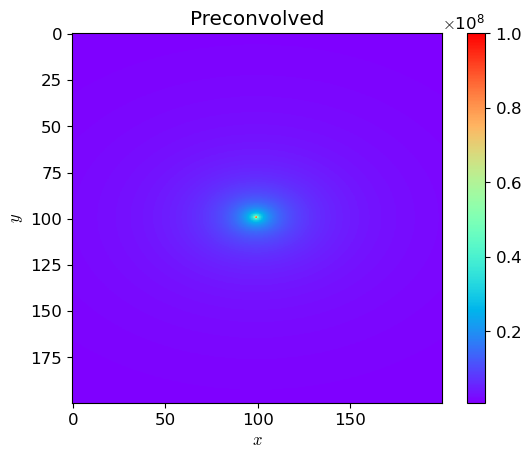

In [5]:
#Copy and pasted elliptical source creation from a previous notebook

#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,200,200)

#Create the y coordinates
yCoords = np.linspace(1,200,200)

print(xCoords)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 100
yCenter = 100

#Set the eccentricity of the ellipse 
e = 0.75

#Set the angle of rotation (in degrees)
theta = 0

#Compute the angle of rotation in radians
theta = math.radians(theta)
print(theta)

#Solve for the semimajor axis length at all points within the mesh grid

deltaX = xField - xCenter
deltaY = yField - yCenter

a = np.sqrt((deltaX*math.cos(theta) - deltaY*math.sin(theta))**2 + (deltaY*math.cos(theta) + deltaX*math.sin(theta))**2 / (1 - e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 300

I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))


#Generate a plot

plt.imshow(I, cmap = 'rainbow')

cbar = plt.colorbar()
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.update_ticks()

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12

#Enable the use of latex writing for the plot
#plt.rcParams['text.usetex'] = True
plt.title('Preconvolved')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

#text = '\n'.join((
#    rf'$Sersic \ Model$',
#    rf'$I_0 = {I_o:.1e}$ ',
#    rf'$n = {n}$',
#   rf'$R_e = {R_e}$'))


props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#plt.savefig('PreconvolvedSource.png')
#plt.text(5, 5, fontsize=14, verticalalignment='top', bbox = props)
plt.show()

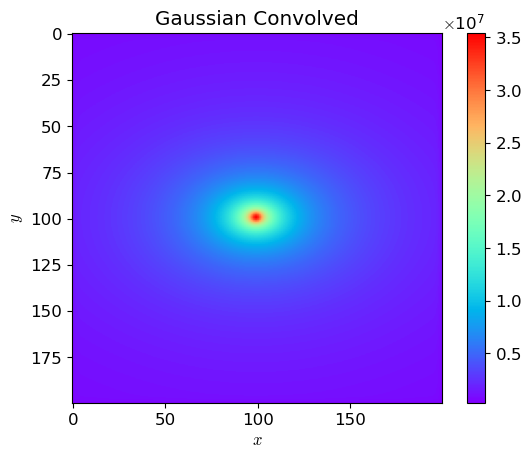

In [7]:
#Trying to create a convoluation kernel to smooth the elliptical galaxy image
#Want to use a 2D Gaussian convolution kernel from astropy

#Set the FWHM of the kernel (in pixels)
#Must be greater than 3 pixels to be larger than the VISTA stellar source PSF

FWHM = 4

#Find the standard deviation of the gaussian based on the FWHM

std_dev = FWHM/(2*np.sqrt(2*np.log(2)))

#Create the Gaussian kernel

kernel = Gaussian2DKernel(std_dev, std_dev)

#Convolve the galaxy source data with the kernel

convolved_image1 = convolve(I, kernel)

#Plot the new convolved image

plt.imshow(convolved_image1, cmap = 'rainbow')

cbar = plt.colorbar()
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.update_ticks()

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12

#Enable the use of latex writing for the plot
#plt.rcParams['text.usetex'] = True
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title('Gaussian Convolved')

#text = '\n'.join((
#    rf'$Sersic \ Model$',
 #   rf'$I_0 = {I_o:.1e}$ ',
  #  rf'$n = {n}$',
   # rf'$R_e = {R_e}$'))


props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#plt.savefig('GaussianConvolvedSource.png')
#plt.text(5, 5, text, fontsize=14, verticalalignment='top', bbox = props)
plt.show()

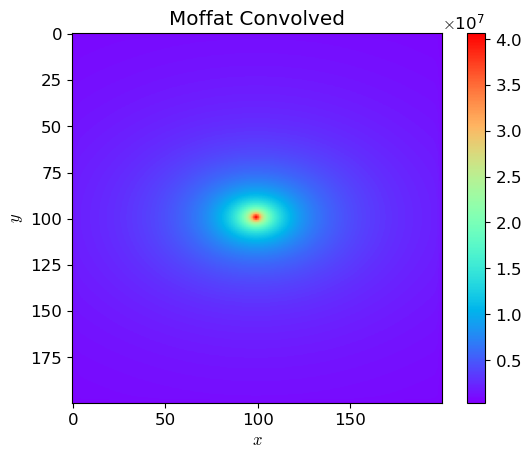

In [9]:
#Using Moffat convolution based on the parameters Amy gave

gamma = 3.1596
alpha = 4.2593

kernel = Moffat2DKernel(gamma, alpha)

#Convolve the galaxy source data with the kernel

convolved_image2 = convolve(I, kernel)

#Plot the new convolved image

plt.imshow(convolved_image2, cmap = 'rainbow')

cbar = plt.colorbar()
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.update_ticks()

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12

#Enable the use of latex writing for the plot
#plt.rcParams['text.usetex'] = True
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title('Moffat Convolved')

#text = '\n'.join((
#    rf'$Sersic \ Model$',
 #   rf'$I_0 = {I_o:.1e}$ ',
  #  rf'$n = {n}$',
   # rf'$R_e = {R_e}$'))


props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#plt.savefig('MoffatConvolvedSource.png')
#plt.text(5, 5, text, fontsize=14, verticalalignment='top', bbox = props)
plt.show()

Preconvolved Sum: 2483176374.848758
Gaussian Convolved Sum: 2454816584.0181923
Moffat Convolved Sum: 2471157854.1556273


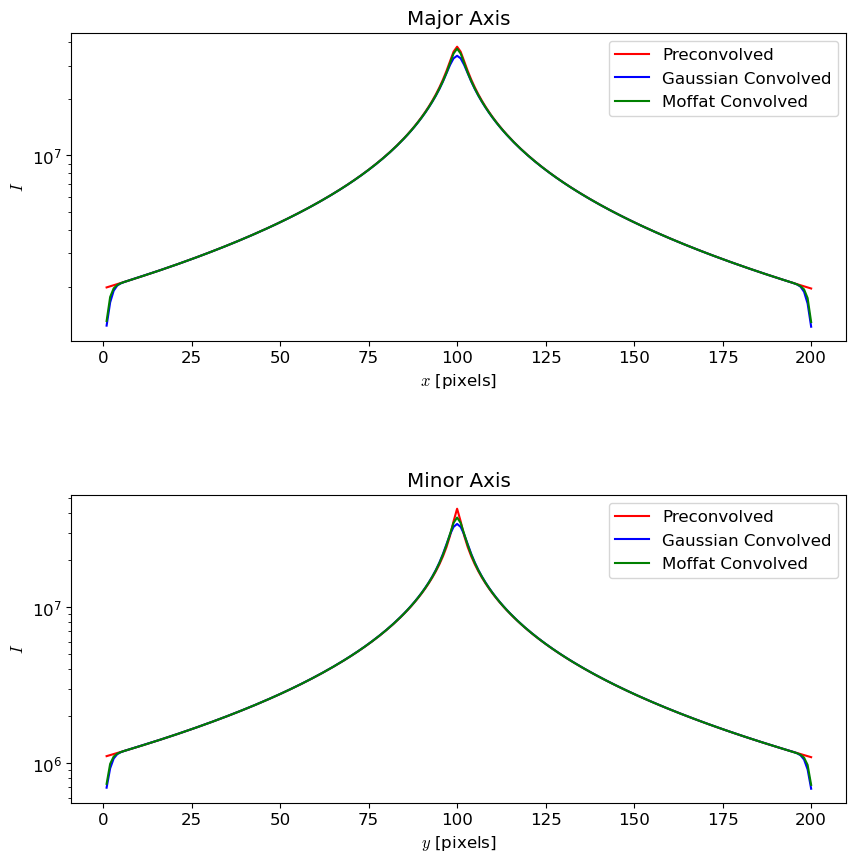

In [23]:
#Generate plots along the semimajor and semiminor axes

#Grab the data from the pre- and post-convolved images

preconvolved_semimajor_data = I[100,:]
#print(preconvolved_semimajor_data[100])
preconvolved_semiminor_data = I[:,100]

postconvolved_Gaussian_semimajor_data = convolved_image1[100,:]
#print(postconvolved_semimajor_data[100])
postconvolved_Gaussian_semiminor_data = convolved_image1[:,100]

postconvolved_Moffat_semimajor_data = convolved_image2[100,:]
#print(postconvolved_semimajor_data[100])
postconvolved_Moffat_semiminor_data = convolved_image2[:,100]

print('Preconvolved Sum: ' +str(np.sum(preconvolved_semimajor_data) + np.sum(preconvolved_semiminor_data)))
print('Gaussian Convolved Sum: ' +str(np.sum(postconvolved_Gaussian_semimajor_data) + np.sum(postconvolved_Gaussian_semiminor_data)))
print('Moffat Convolved Sum: ' + str(np.sum(postconvolved_Moffat_semimajor_data) + np.sum(postconvolved_Moffat_semiminor_data)))

#Generate an axis to plot the data against
axis = np.linspace(1,200,200)

#Create subplots for each set of data

fig, (ax1, ax2) = plt.subplots(2,1, figsize = (10,10))
fig.subplots_adjust(hspace=0.5)

ax1.plot(axis, preconvolved_semimajor_data, 'r', label = 'Preconvolved') 
ax1.plot(axis, postconvolved_Gaussian_semimajor_data, 'b', label = 'Gaussian Convolved' )
ax1.plot(axis, postconvolved_Moffat_semimajor_data, 'g', label = 'Moffat Convolved')
ax1.set_yscale('log')
ax1.set_xscale('linear')
#ax1.set_xlim(120,170)
#ax1.set_ylim(1*10**6, 4.5*10**7)
#ax1.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
ax1.set_title('Major Axis')
ax1.set_xlabel('$x$ [pixels]')
ax1.set_ylabel('$I$')
ax1.legend()

ax2.plot(axis, preconvolved_semiminor_data, 'r', label = 'Preconvolved') 
ax2.plot(axis, postconvolved_Gaussian_semiminor_data, 'b', label = 'Gaussian Convolved')
ax2.plot(axis, postconvolved_Moffat_semiminor_data, 'g', label = 'Moffat Convolved')
ax2.set_yscale('log')
ax2.set_xscale('linear')
#ax2.set_xlim(120, 170)
#ax2.set_ylim(1*10**6, 4.5*10**7)
#ax2.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
ax2.set_title('Minor Axis')
ax2.set_xlabel('$y$ [pixels]')
ax2.set_ylabel('$I$')
ax2.legend()

#plt.savefig('ConvolutionAxisProfileComparison_Semilogy.png')               
plt.show()

In [25]:
print(np.sum(I))
print(np.sum(convolved_image1))
print(np.sum(convolved_image2))

109474278540.37909
108830114143.94096
108962618021.67804
